# Exercicios adicionais PDE / Fourier 24/09/2026
### Brais Otero Lema

Exercise 1.1: Laplace equation

 34%|███▍      | 1703/5000 [00:00<00:00, 55679.06it/s]


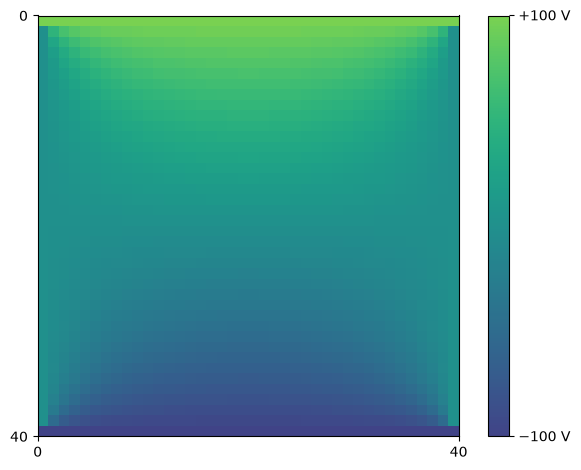

In [1]:
import numpy as np
from matplotlib.pyplot import subplots
from tqdm import tqdm
from cmasher import get_sub_cmap
from matplotlib.ticker import FixedFormatter
from matplotlib.colors import Normalize, LogNorm
from matplotlib.colorizer import Colorizer

def get_boundary(side):
    V = np.zeros((side, side))
    boundary_mask = np.zeros_like(V, dtype=bool)
    boundary_values = np.zeros_like(V)

    boundary_mask[:,0] = True
    boundary_mask[:,-1] = True

    V[0,:] = +100
    boundary_mask[0,:] = True
    boundary_values[0,:] = V.copy()[0,:]

    V[-1,:] = -100
    boundary_mask[-1,:] = True
    boundary_values[-1,:] = V.copy()[-1,:]

    return V, boundary_mask, boundary_values

def gauss_seidel_rb_step(V, mask, mask_values):
    V[1:-1:2,1:-1:2] = 0.25*(
        V[:-2:2,1:-1:2] + V[2::2,1:-1:2] +
        V[1:-1:2,:-2:2] + V[1:-1:2,2::2]
    )
    V[2:-1:2,2:-1:2] = 0.25*(
        V[1:-2:2,2:-1:2] + V[3::2,2:-1:2] +
        V[2:-1:2,1:-2:2] + V[2:-1:2,3::2]
    )

    V[2:-1:2,1:-1:2] = 0.25*(
        V[1:-2:2,1:-1:2] + V[3::2,1:-1:2] +
        V[2:-1:2,:-2:2] + V[2:-1:2,2::2]
    )
    V[1:-1:2,2:-1:2] = 0.25*(
        V[:-2:2,2:-1:2] + V[2::2,2:-1:2] +
        V[1:-1:2,1:-2:2] + V[1:-1:2,3::2]
    )

    V[mask] = mask_values[mask]
    return V

tolerance = 1e-12
maximum_steps = 5000
side = 40

fig, ax = subplots()

norm = Normalize(vmin=-100, vmax=+100)
colorizer = Colorizer(norm=norm, cmap=get_sub_cmap("viridis", .2, .8))

V_initial, boundary_mask, boundary_values = get_boundary(side)
V_prev = V_initial.copy()

for step in tqdm(range(maximum_steps)):
    V_check = V_prev.copy()
    V_step = gauss_seidel_rb_step(V_prev, boundary_mask, boundary_values)

    below_tolerance = np.all(np.abs(V_step - V_check) < tolerance)
    if not below_tolerance:
        V_prev = V_step.copy()
    else:
        break

cax = ax.imshow(V_step, colorizer=colorizer)

ax.set_xticks([-.5, side-.5])
ax.set_yticks([-.5, side-.5])

ax.set_xticklabels(["0", "40"])
ax.set_yticklabels(["0", "40"])

fig.colorbar(cax, ax=ax, location="right", orientation="vertical", fraction=.1, ticks=[norm.vmin, norm.vmax], format=FixedFormatter([r"$-100$ V", r"$+100$ V"]))

fig.tight_layout()

Exercise 1.2: Poisson equation

100%|██████████| 20000/20000 [00:04<00:00, 4047.74it/s]


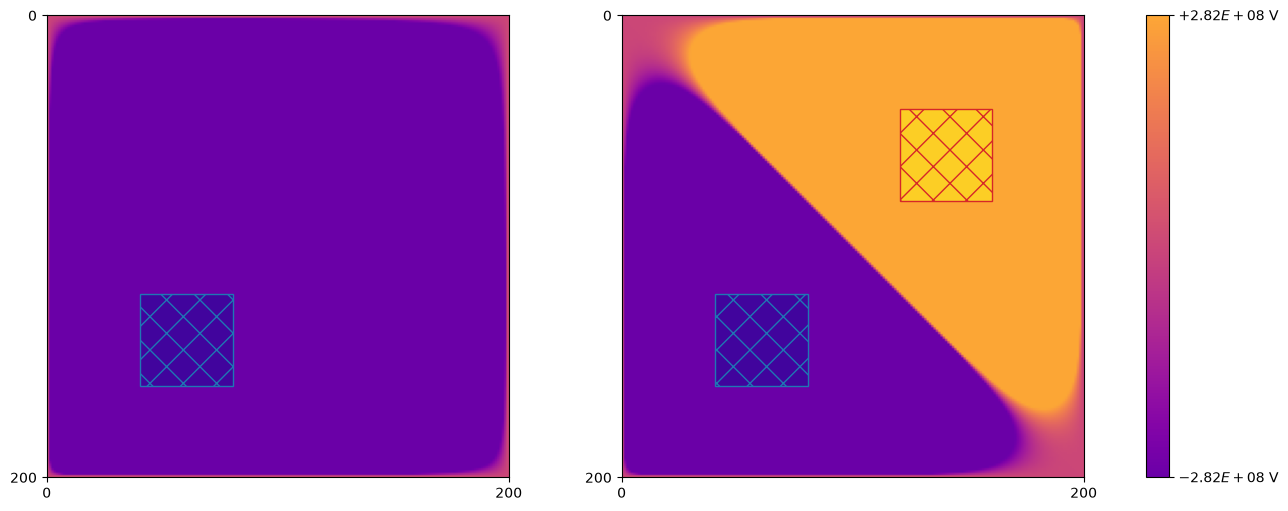

In [2]:
import numpy as np
from matplotlib.pyplot import subplots
from tqdm import tqdm
from cmasher import get_sub_cmap
from matplotlib.ticker import FixedFormatter
from matplotlib.colors import Normalize, LogNorm
from matplotlib.colorizer import Colorizer
from matplotlib.patches import Rectangle

def jacobi_step(V):
    V_new = V.copy()
    V_new[1:-1, 1:-1] = .25 * (V[1:-1, :-2] + V[1:-1, 2:] + V[:-2, 1:-1] + V[2:, 1:-1])
    return V_new

length = 100
rho = 1e-4
extension = 20

tolerance = 1e-12
maximum_steps = 20_000
side = 200

h = length/side
eps = 8.854e-14

fig, axs = subplots(1, 2, figsize=(16, 6))

vmin, vmax = -rho*h**2/eps, +rho*h**2/eps

norm = Normalize(vmin=vmin, vmax=vmax)
colorizer = Colorizer(norm=norm, cmap=get_sub_cmap("plasma", .2, .8))

rho_matrix_neg = np.zeros((side, side))
rho_matrix_neg[int(.6*side):int(.8*side), int(.2*side):int(.4*side)] = -rho

rho_matrix_both = rho_matrix_neg.copy()
rho_matrix_both[int(.2*side):int(.4*side), int(.6*side):int(.8*side)] = rho

rho_matrices = (rho_matrix_neg, rho_matrix_both)

neg_rect = Rectangle((int(.2*side), int(.6*side)), int(.2*side), int(.2*side), fc=get_sub_cmap("plasma", .1, .8).colors[0], hatch="x", ec="tab:blue")

neg_rect2 = Rectangle((int(.2*side), int(.6*side)), int(.2*side), int(.2*side), fc=get_sub_cmap("plasma", .1, .8).colors[0], hatch="x", ec="tab:blue")
pos_rect = Rectangle((int(.6*side), int(.2*side)), int(.2*side), int(.2*side), fc=get_sub_cmap("plasma", .2, .9).colors[-1], hatch="x", ec="tab:red")

rects_col = [[neg_rect], [neg_rect2, pos_rect]]

for rho_matrix, ax, rects in zip(rho_matrices, axs, rects_col):

    V_initial = np.zeros((side, side))
    V_prev = V_initial.copy()

    for step in tqdm(range(maximum_steps)):
        V_step = jacobi_step(V_prev)
        V_step[1:-1] += h**2/4/eps * rho_matrix[1:-1]

        below_tolerance = np.all(np.abs(V_step - V_prev) < tolerance)
        if not below_tolerance:
            V_prev = V_step.copy()
        else:
            break

    cax = ax.imshow(V_step, colorizer=colorizer)

    for rect in rects:
        ax.add_patch(rect)

    ax.set_xticks([-.5, side-.5])
    ax.set_yticks([-.5, side-.5])

    ax.set_xticklabels(["0", f"{side}"])
    ax.set_yticklabels(["0", f"{side}"])

fig.colorbar(cax, ax=axs, location="right", orientation="vertical", fraction=.1, ticks=[norm.vmin, norm.vmax], format=FixedFormatter([f"${vmin:.2E}$ V", f"$+{vmax:.2E}$ V"]))

Exercise 1.3: Heat flux

  5%|▍         | 242/5000 [00:00<00:00, 27755.58it/s]


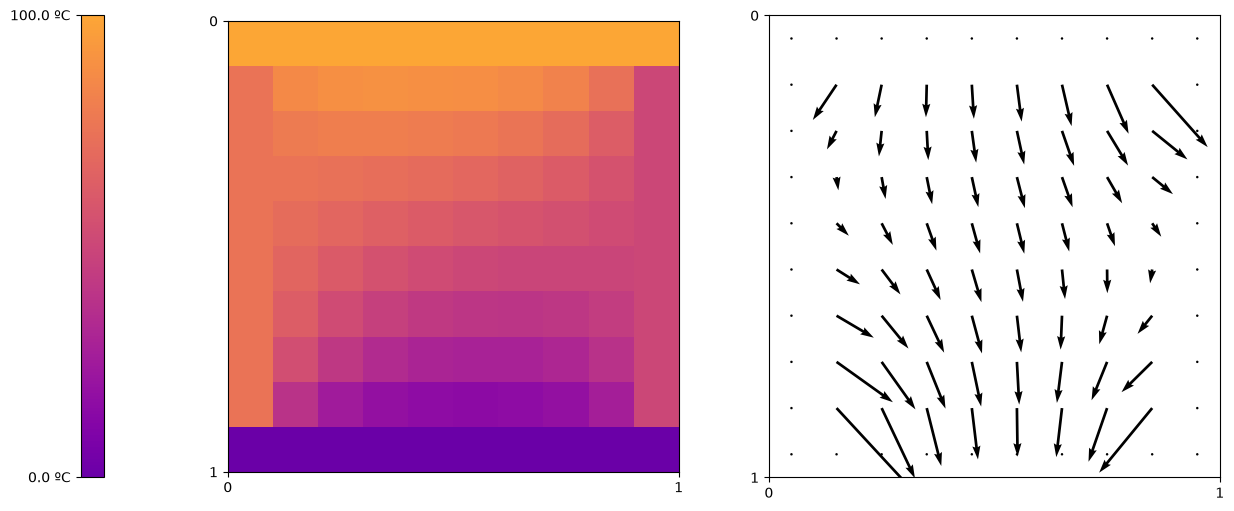

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from cmasher import get_sub_cmap
from matplotlib.ticker import FixedFormatter
from matplotlib.colors import Normalize
from matplotlib.colorizer import Colorizer

def get_boundary(side):
    V = np.zeros((side, side))
    boundary_mask = np.zeros_like(V, dtype=bool)
    boundary_values = np.zeros_like(V)

    V[:,0] = 75
    boundary_mask[:,0] = True
    boundary_values[:,0] = V.copy()[:,0]

    V[:,-1] = 50
    boundary_mask[:,-1] = True
    boundary_values[:,-1] = V.copy()[:,-1]

    V[0,:] = 100
    boundary_mask[0,:] = True
    boundary_values[0,:] = V.copy()[0,:]

    V[-1,:] = 0
    boundary_mask[-1,:] = True
    boundary_values[-1,:] = V.copy()[-1,:]

    return V, boundary_mask, boundary_values

def gauss_seidel_rb_step(V, mask, mask_values):
    V[1:-1:2,1:-1:2] = 0.25*(
        V[:-2:2,1:-1:2] + V[2::2,1:-1:2] +
        V[1:-1:2,:-2:2] + V[1:-1:2,2::2]
    )
    V[2:-1:2,2:-1:2] = 0.25*(
        V[1:-2:2,2:-1:2] + V[3::2,2:-1:2] +
        V[2:-1:2,1:-2:2] + V[2:-1:2,3::2]
    )

    V[2:-1:2,1:-1:2] = 0.25*(
        V[1:-2:2,1:-1:2] + V[3::2,1:-1:2] +
        V[2:-1:2,:-2:2] + V[2:-1:2,2::2]
    )
    V[1:-1:2,2:-1:2] = 0.25*(
        V[:-2:2,2:-1:2] + V[2::2,2:-1:2] +
        V[1:-1:2,1:-2:2] + V[1:-1:2,3::2]
    )

    V[mask] = mask_values[mask]
    return V

exact = lambda x, y : np.sin(np.pi*x) * np.sinh(np.pi*y) / np.sinh(np.pi)

tolerance = 1e-12
maximum_steps = 5_000

side = 10
conductivity = .49
length = 40
h = length / side

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

norm = Normalize(vmin=0, vmax=100)
colorizer = Colorizer(norm=norm, cmap=get_sub_cmap("plasma", .2, .8))


V_initial, boundary_mask, boundary_values = get_boundary(side)
V_prev = V_initial.copy()

for step in tqdm(range(maximum_steps)):
    V_check = V_prev.copy()
    V_step = gauss_seidel_rb_step(V_prev, boundary_mask, boundary_values)

    below_tolerance = np.all(np.abs(V_step - V_check) < tolerance)
    if not below_tolerance:
        V_prev = V_step.copy()
    else:
        break

flux_x, flux_y = np.zeros_like(V_initial), np.zeros_like(V_initial)

flux_x[1:-1, 1:-1] = -conductivity/2/h * (V_step[1:-1, 2:] - V_step[1:-1, :-2])
flux_y[1:-1, 1:-1] = -conductivity/2/h * (V_step[2:, 1:-1] - V_step[:-2, 1:-1])

cax = axs[0].imshow(V_step, colorizer=colorizer)

axs[1].quiver(flux_x, -flux_y)
axs[1].yaxis.set_inverted(True)

for ax in axs:
    ax.set_xticks([-.5, side-.5])
    ax.set_yticks([-.5, side-.5])

    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

fig.colorbar(cax, ax=axs, location="left", orientation="vertical", fraction=.1, ticks=[norm.vmin, norm.vmax], format=FixedFormatter([f"${norm.vmin}$ ºC", f"${norm.vmax}$ ºC"]))

Exercise 2.1: Steel bar

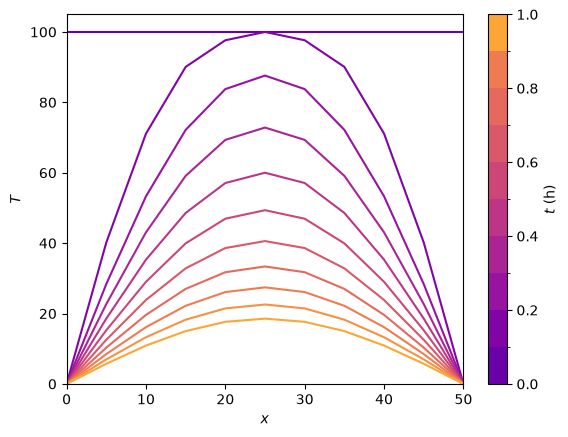

In [4]:
import numpy as np
from matplotlib.pyplot import subplots
from cmasher import get_sub_cmap
from matplotlib.colors import BoundaryNorm
from matplotlib.colorizer import Colorizer, ColorizingArtist

def ftcs_step(T, r, step):
    T[step+1, 1:-1] = T[step, 1:-1] + r * (T[step, 2:] + T[step, :-2] - 2*T[step, 1:-1])
    return T

length = 50
conductivity = .12
specific_heat = .113
density = 7.8
timelength = 1

dx = 5
N = 1 + int(length/dx)
xlin = np.linspace(0, length, N)

dt = .02
timesteps = 1 + int(timelength/dt)

r = (conductivity/specific_heat/density) * dt*3600 / dx**2

T_initial = np.zeros((timesteps, N))
T_initial[0, :] = 100

T_step = T_initial.copy()
for timestep in range(timesteps-1):
    T_step = ftcs_step(T_step, r, timestep)
    T_step[timestep+1, 0], T_step[timestep+1, -1] = 0, 0

fig, ax = subplots()

ts = np.arange(timesteps)[::5]
cmap = get_sub_cmap("plasma", .2, .8, N=len(ts))
for t, c in zip(ts, cmap.colors):
    ax.plot(xlin, T_step[t, :], ls="solid", color=c)

ax.set_xlim(left=np.min(xlin), right=np.max(xlin))

ax.set_ylim(bottom=0)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$T$")

bounds = ts*dt
norm = BoundaryNorm(bounds, cmap.N)
colorizer = Colorizer(norm=norm, cmap=cmap)

fig.colorbar(ColorizingArtist(colorizer), ax=ax, orientation="vertical", location="right", label=r"$t$ (h)")

Exercise 3.1: Various functions

Function Sawtooth
a_0 = 8.0
a_1 = 7.771561172376096e-16
a_2 = -1.6653345369377348e-15
b_1 = 1.9098593171027443
b_2 = -0.9549296585513721
Function Wavy
a_0 = 4.166666666666667
a_1 = -2.533029591058445
a_2 = 0.6332573977646105
b_1 = 7.957747154594768
b_2 = -3.978873577297384
Function Spiky
a_0 = 0.0
a_1 = 0.0
a_2 = 0.0
b_1 = 0.6366197723675814
b_2 = -7.272153279333111e-18


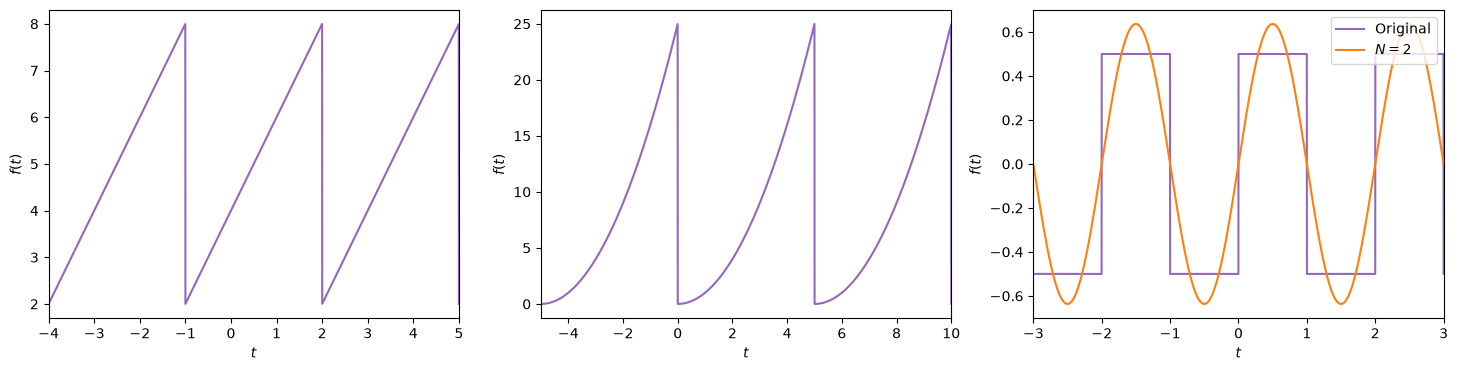

In [5]:
import numpy as np
from matplotlib.pyplot import subplots
from scipy.integrate import quad

funcs = (
    lambda t : 2*t + 4,
    lambda t : t**2,
    lambda t : .5 - np.heaviside(-t, 0)
)

periods = (3, 5, 2)

definition_bounds = ([-1, 2], [0, 5], [-1, 1])
extended_bounds = ([-4, 5], [-5, 10], [-3, 3])

names = ("Sawtooth", "Wavy", "Spiky")

interval_mapping = lambda x, original, target : ((x - np.min(original)) % period) + np.min(target)

sample_size = 1000

fig, axs = subplots(1, 3, figsize=(18, 4))

for func, period, bounds, ex_bounds, ax, name in zip(funcs, periods, definition_bounds, extended_bounds, axs, names):

    definition_interval = np.linspace(bounds[0], bounds[1], sample_size)
    extended_interval = np.linspace(ex_bounds[0], ex_bounds[1], 3*sample_size)
    tlin = np.linspace(-period/2, period/2, sample_size)

    ax.plot(extended_interval, func(interval_mapping(extended_interval, extended_interval, definition_interval)), ls="solid", color="tab:purple", label="Original")

    ax.set_xlim(left=np.min(extended_interval), right=np.max(extended_interval))

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$f(t)$")

    a_0 = 2/period * quad(func, np.min(tlin), np.max(tlin))[0]

    a_n_func = lambda x, n : func(interval_mapping(x, tlin, definition_interval)) * np.cos(n*2*np.pi/period * x)
    a_n = lambda n : 2/period * quad(a_n_func, np.min(tlin), np.max(tlin), args=(n))[0]

    b_n_func = lambda x, n : func(interval_mapping(x, tlin, definition_interval)) * np.sin(n*2*np.pi/period * x)
    b_n = lambda n : 2/period * quad(b_n_func, np.min(tlin), np.max(tlin), args=(n))[0]

    print(f"Function {name}")
    print(f"a_0 = {a_0}")
    print(f"a_1 = {a_n(1)}")
    print(f"a_2 = {a_n(2)}")
    print(f"b_1 = {b_n(1)}")
    print(f"b_2 = {b_n(2)}")

sum_term = lambda x, n : a_n(n) * np.cos(n*2*np.pi/period * x) + b_n(n) * np.sin(n*2*np.pi/period * x)
def partial_sum(x, N):
    s = a_0/2
    for n in range(1, N+1):
        s += sum_term(x, n)
    return s

axs[-1].plot(extended_interval, partial_sum(extended_interval, 2), ls="solid", color="tab:orange", label=r"$N = 2$")

axs[-1].legend(loc="upper right")

Exercise 3.2: Piano

Power peaks at frequency f = 1190 Hz.
Entering it at https://www.phys.unsw.edu.au/music/note/, it corresponds to a D6 plus 22 cents.
En galego, un Re dúas escalas por encima do Do central.


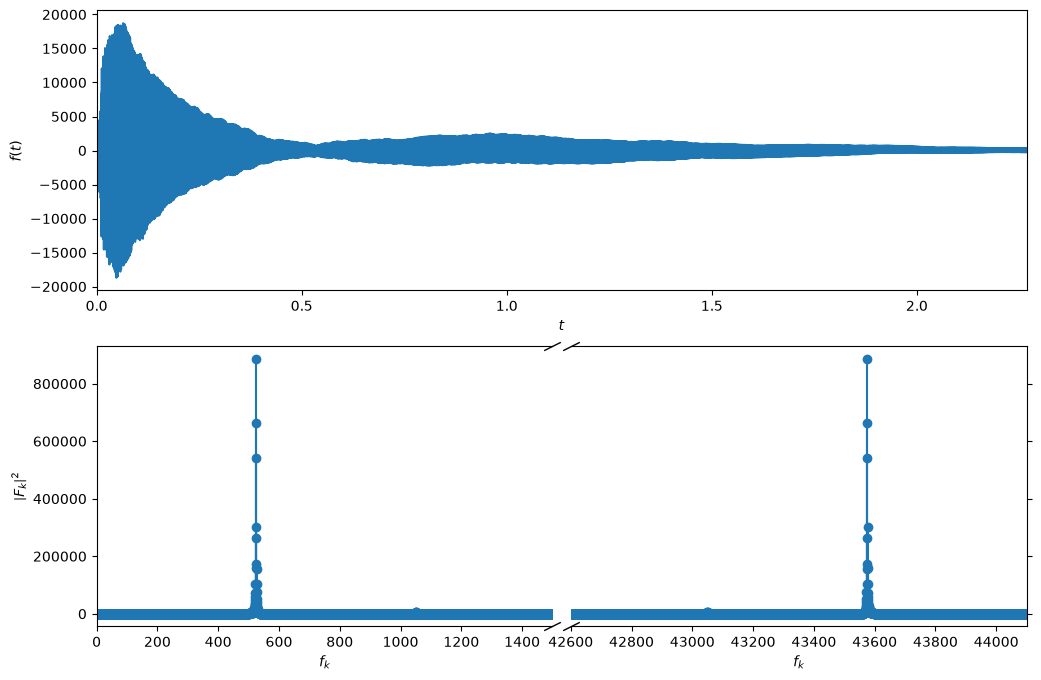

In [6]:
import numpy as np
from numpy.fft import fft
from matplotlib.pyplot import subplot_mosaic

# Será necesario cambiar isto para que funcione o notebook
signal = np.loadtxt("/home/luna/projects/adcompu/numerical-methods/xabier/extras/piano.txt")

sampling_speed = 44_100
sample_number = len(signal)
sampling_start, sampling_end = 0, sample_number/sampling_speed
sampling_interval = np.linspace(sampling_start, sampling_end, sample_number, endpoint=False)
frequencies = np.arange(len(sampling_interval)) / (sampling_end - sampling_start)

coefficients = fft(signal)

fig, axs = subplot_mosaic([["signal", "signal"], ["power left", "power right"]], figsize=(12,8))

axs["signal"].plot(sampling_interval, signal, ls="solid")

axs["signal"].set_xlim(left=np.min(sampling_interval), right=np.max(sampling_interval))

axs["signal"].set_xlabel(r"$t$")
axs["signal"].set_ylabel(r"$f(t)$")

power_spectrum = np.abs(coefficients/len(sampling_interval))**2
for ax in (axs["power left"], axs["power right"]):
    ax.stem(frequencies, power_spectrum, basefmt=" ")

    ax.set_xlabel(r"$f_k$")


axs["power left"].set_ylabel(r"$\left\vert F_k \right\vert^2$")

fig.subplots_adjust(wspace=.04)

axs["power left"].set_xlim(left=0, right=1_500)
axs["power right"].set_xlim(left=44_100-1_500, right=44_100)

axs["power left"].spines.right.set_visible(False)
axs["power right"].spines.left.set_visible(False)

axs["power left"].yaxis.tick_left()
axs["power right"].yaxis.tick_right()
axs["power right"].tick_params(labelright=False)

d = .5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color="k", mec="k", mew=1, clip_on=False)

axs["power left"].plot([1, 1], [0, 1], transform=axs["power left"].transAxes, **kwargs)
axs["power right"].plot([0, 0], [0, 1], transform=axs["power right"].transAxes, **kwargs)

print(f"Power peaks at frequency f = {np.argmax(power_spectrum)} Hz.")
print(f"Entering it at https://www.phys.unsw.edu.au/music/note/, it corresponds to a D6 plus 22 cents.")
print(f"En galego, un Re dúas escalas por encima do Do central.")